# Stock Price Forecasting — Transformer

**Model:** Transformer Encoder Regressor  
**Dữ liệu:** 5 mã VCB, FPT, HPG, VIC, VNM — Close Price  
**Chỉ số đánh giá:** RMSE, MAE, MAPE, R², Directional Accuracy

Notebook này giữ cấu trúc của `00_template.ipynb` và thay phần TODO bằng một Transformer nhỏ dùng PyTorch. Model dự báo one-step-ahead: mỗi điểm test được dự báo từ cửa sổ dữ liệu quá khứ đã biết.


---
## Section 0 — Setup chung

In [32]:
import warnings
warnings.filterwarnings('ignore')

import json
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "Notebook 08 cần PyTorch. Chạy: python -m pip install torch"
    ) from exc

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print('DEVICE:', DEVICE)

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120})


DEVICE: mps


In [33]:
# ── Cấu hình đường dẫn ──
ROOT        = Path('..').resolve()
SPLITS_DIR  = ROOT / 'data' / 'processed' / 'splits'
FEATURED_DIR = ROOT / 'data' / 'processed' / 'featured'

TICKERS = ['VCB', 'FPT', 'HPG', 'VIC', 'VNM']
SPLITS  = ['70_30', '80_20']

MODEL_NAME = 'Transformer'

LOOKBACK = 30
BATCH_SIZE = 64
EPOCHS = 40
PATIENCE = 6
LEARNING_RATE = 1e-3

RESULTS_DIR = ROOT / 'results' / MODEL_NAME.lower().replace(' ', '_')
PLOTS_DIR   = RESULTS_DIR / 'plots'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print('ROOT:', ROOT)
print('SPLITS_DIR:', SPLITS_DIR)
print('MODEL:', MODEL_NAME)


ROOT: /Users/hobaoan/Desktop/stock-time-series-main
SPLITS_DIR: /Users/hobaoan/Desktop/stock-time-series-main/data/processed/splits
MODEL: Transformer


---
## Section 1 — Hàm tiện ích (dùng chung, không sửa)

In [34]:
def load_split(ticker: str, split: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Load train/test DataFrames cho một mã và một tỷ lệ split."""
    base = SPLITS_DIR / split
    train = pd.read_csv(base / f'{ticker}_train.csv', parse_dates=['date'])
    test  = pd.read_csv(base / f'{ticker}_test.csv',  parse_dates=['date'])
    return train.sort_values('date').reset_index(drop=True), \
           test.sort_values('date').reset_index(drop=True)

In [35]:
# ── compute_metrics — single source of truth tại src/metrics.py ──
# Trả về dict gồm: RMSE, MAE, MAPE (%), R²
# Truyền `prev_close` (giá đóng cửa của ngày liền trước) để có thêm "Directional Accuracy (%)".
import sys as _sys
_sys.path.insert(0, str(ROOT))
from src.metrics import compute_metrics  # noqa: E402


In [36]:
def plot_predictions(
    dates,
    y_true,
    y_pred,
    ticker: str,
    split: str,
    model_name: str,
    metrics: dict,
    save: bool = True,
) -> None:
    """Vẽ biểu đồ Actual vs Predicted và lưu file PNG."""
    fig, ax = plt.subplots(figsize=(14, 4.5))

    ax.plot(dates, y_true, label='Actual',    color='#2563EB', linewidth=1.2, alpha=0.85)
    ax.plot(dates, y_pred, label='Predicted', color='#DC2626', linewidth=1.2, alpha=0.85, linestyle='--')

    ratio_label = split.replace('_', '/')
    subtitle = (f"RMSE={metrics['RMSE']:,.2f}  "
                f"MAE={metrics['MAE']:,.2f}  "
                f"MAPE={metrics['MAPE (%)']:.2f}%  "
                f"R²={metrics['R²']:.4f}")
    ax.set_title(f"{model_name} — {ticker}  (Split {ratio_label})\n{subtitle}", pad=10)
    ax.set_xlabel('Ngày')
    ax.set_ylabel('Giá đóng cửa (VND × nghìn)')
    ax.legend(loc='upper left')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.xticks(rotation=35, ha='right')
    ax.grid(axis='y', linestyle=':', alpha=0.5)
    plt.tight_layout()

    if save:
        fname = PLOTS_DIR / f"{ticker}_{split}_{model_name.lower().replace(' ', '_')}.png"
        fig.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

In [37]:
def build_results_table(all_results: list[dict]) -> pd.DataFrame:
    """Tạo bảng tổng hợp RMSE/MAE/MAPE/R² (+ Directional Accuracy nếu có) cho tất cả mã và splits."""
    df = pd.DataFrame(all_results)
    cols = ['Ticker', 'Split', 'Model', 'RMSE', 'MAE', 'MAPE (%)', 'R²']
    if 'Directional Accuracy (%)' in df.columns:
        cols.append('Directional Accuracy (%)')
    df = df[cols].sort_values(['Split', 'Ticker']).reset_index(drop=True)
    df[['RMSE', 'MAE']] = df[['RMSE', 'MAE']].round(2)
    df['MAPE (%)'] = df['MAPE (%)'].round(3)
    df['R²'] = df['R²'].round(4)
    if 'Directional Accuracy (%)' in df.columns:
        df['Directional Accuracy (%)'] = df['Directional Accuracy (%)'].round(2)
    return df


---
## Section 2 — Feature Engineering

Transformer dùng cửa sổ `LOOKBACK` ngày quá khứ để dự báo close của ngày kế tiếp. Feature được scale bằng thống kê của train set, sau đó áp dụng cho test set để tránh leakage.


In [38]:
def add_time_series_features(df: pd.DataFrame) -> pd.DataFrame:
    """Tạo feature chỉ dùng thông tin hiện tại/quá khứ tại mỗi dòng."""
    out = df.sort_values('date').copy()
    out['return_1'] = out['close'].pct_change().replace([np.inf, -np.inf], np.nan)
    out['ma_5'] = out['close'].rolling(5, min_periods=1).mean()
    out['ma_10'] = out['close'].rolling(10, min_periods=1).mean()
    out['volatility_5'] = out['return_1'].rolling(5, min_periods=2).std()
    out['close_lag_1'] = out['close'].shift(1)

    if 'volume' in out.columns:
        out['volume_change'] = out['volume'].pct_change().replace([np.inf, -np.inf], np.nan)
    else:
        out['volume_change'] = 0.0

    return out.ffill().bfill().fillna(0.0)


def make_supervised_sequences(features: np.ndarray, target: np.ndarray, start_idx: int, lookback: int):
    X, y = [], []
    for idx in range(start_idx, len(target)):
        X.append(features[idx - lookback:idx])
        y.append(target[idx])
    return np.asarray(X, dtype=np.float32), np.asarray(y, dtype=np.float32).reshape(-1, 1)


def prepare_data(train_df: pd.DataFrame, test_df: pd.DataFrame):
    """Chuẩn bị sequence train/test cho Transformer one-step-ahead."""
    full_df = pd.concat([train_df, test_df], ignore_index=True).sort_values('date').reset_index(drop=True)
    full_df = add_time_series_features(full_df)
    n_train = len(train_df)

    feature_cols = ['close', 'return_1', 'ma_5', 'ma_10', 'volatility_5', 'close_lag_1', 'volume_change']
    feature_cols = [col for col in feature_cols if col in full_df.columns]

    feature_scaler = StandardScaler()
    target_scaler = StandardScaler()

    feature_scaler.fit(full_df.loc[:n_train - 1, feature_cols])
    target_scaler.fit(full_df.loc[:n_train - 1, ['close']])

    features_scaled = feature_scaler.transform(full_df[feature_cols])
    target_scaled = target_scaler.transform(full_df[['close']]).ravel()

    X_train, y_train = make_supervised_sequences(features_scaled, target_scaled, LOOKBACK, LOOKBACK)
    X_test, _ = make_supervised_sequences(features_scaled, target_scaled, n_train, LOOKBACK)
    y_test = test_df['close'].to_numpy(dtype=float)

    return X_train, y_train, X_test, y_test, target_scaler, feature_cols


---
## Section 3 — Huấn luyện & Dự báo *(TODO)*

Điền logic train và predict của model vào hàm `train_and_predict`.

In [39]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 500):
        super().__init__()
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class TransformerRegressor(nn.Module):
    def __init__(self, n_features: int, d_model: int = 32, nhead: int = 4, num_layers: int = 2, dropout: float = 0.1):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        self.pos_encoder = PositionalEncoding(d_model, max_len=LOOKBACK + 5)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True,
            activation='gelu',
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 16),
            nn.GELU(),
            nn.Linear(16, 1),
        )

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_encoder(x)
        x = self.encoder(x)
        return self.head(x[:, -1, :])


def train_and_predict(train_df: pd.DataFrame, test_df: pd.DataFrame) -> np.ndarray:
    """Train Transformer trên train_df và dự báo close cho test_df."""
    X_train, y_train, X_test, y_test, target_scaler, feature_cols = prepare_data(train_df, test_df)

    if len(X_train) < 20:
        raise ValueError('Không đủ dữ liệu train cho Transformer. Giảm LOOKBACK hoặc kiểm tra split.')

    split_at = max(int(len(X_train) * 0.9), 1)
    X_tr, y_tr = X_train[:split_at], y_train[:split_at]
    X_val, y_val = X_train[split_at:], y_train[split_at:]
    if len(X_val) == 0:
        X_val, y_val = X_tr, y_tr

    train_loader = DataLoader(
        TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr)),
        batch_size=BATCH_SIZE,
        shuffle=False,
    )

    model = TransformerRegressor(n_features=X_train.shape[-1]).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
    loss_fn = nn.MSELoss()

    X_val_t = torch.tensor(X_val, dtype=torch.float32, device=DEVICE)
    y_val_t = torch.tensor(y_val, dtype=torch.float32, device=DEVICE)

    best_state = None
    best_val = float('inf')
    stale_epochs = 0

    for epoch in range(1, EPOCHS + 1):
        model.train()
        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(X_val_t), y_val_t).item()

        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            stale_epochs = 0
        else:
            stale_epochs += 1
            if stale_epochs >= PATIENCE:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    with torch.no_grad():
        pred_scaled = model(torch.tensor(X_test, dtype=torch.float32, device=DEVICE)).cpu().numpy()

    y_pred = target_scaler.inverse_transform(pred_scaled).ravel()
    return np.clip(y_pred, a_min=0.0, a_max=None)


---
## Section 4 — Vòng lặp chính: Train → Evaluate → Plot

**Không cần sửa** — gọi `train_and_predict` và `compute_metrics` cho mọi (ticker, split).


  Split: 70/30

  > VCB...
     RMSE=1.80  MAE=1.10  MAPE=1.78%  R2=0.7878  DA=53.3%


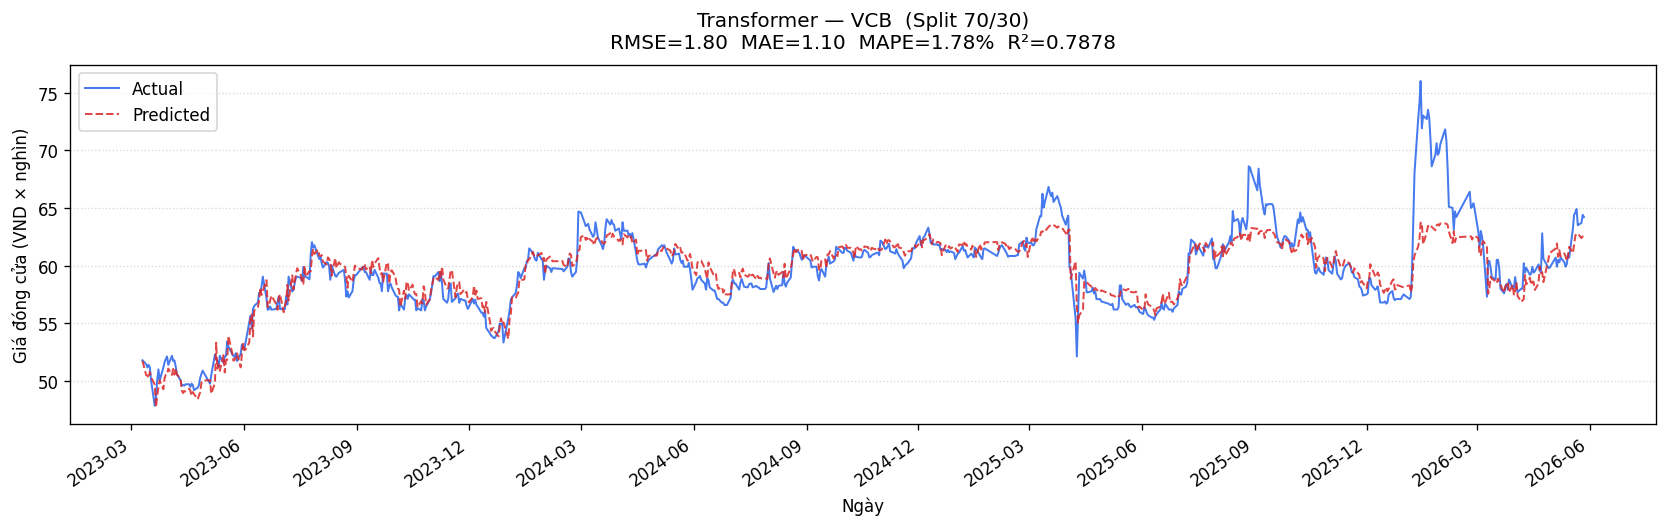


  > FPT...
     RMSE=5.45  MAE=3.84  MAPE=3.96%  R2=0.9408  DA=51.6%


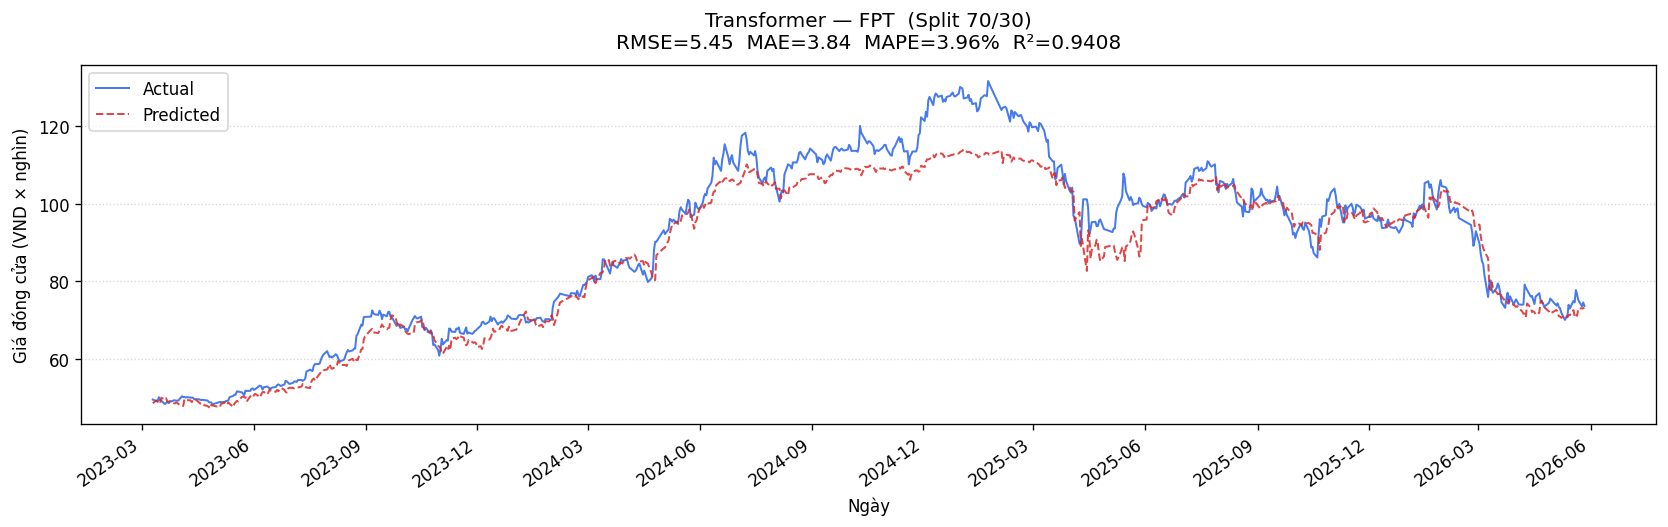


  > HPG...
     RMSE=1.02  MAE=0.87  MAPE=4.38%  R2=0.8843  DA=48.6%


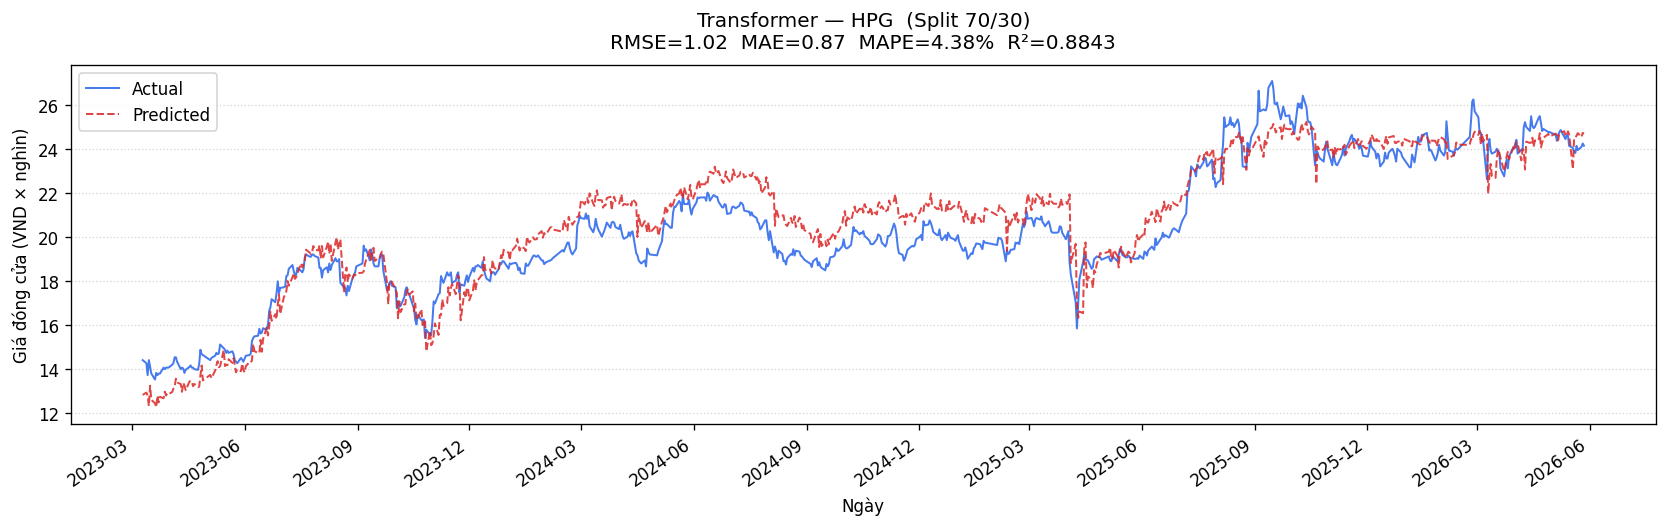


  > VIC...
     RMSE=43.33  MAE=20.07  MAPE=18.66%  R2=0.3175  DA=47.3%


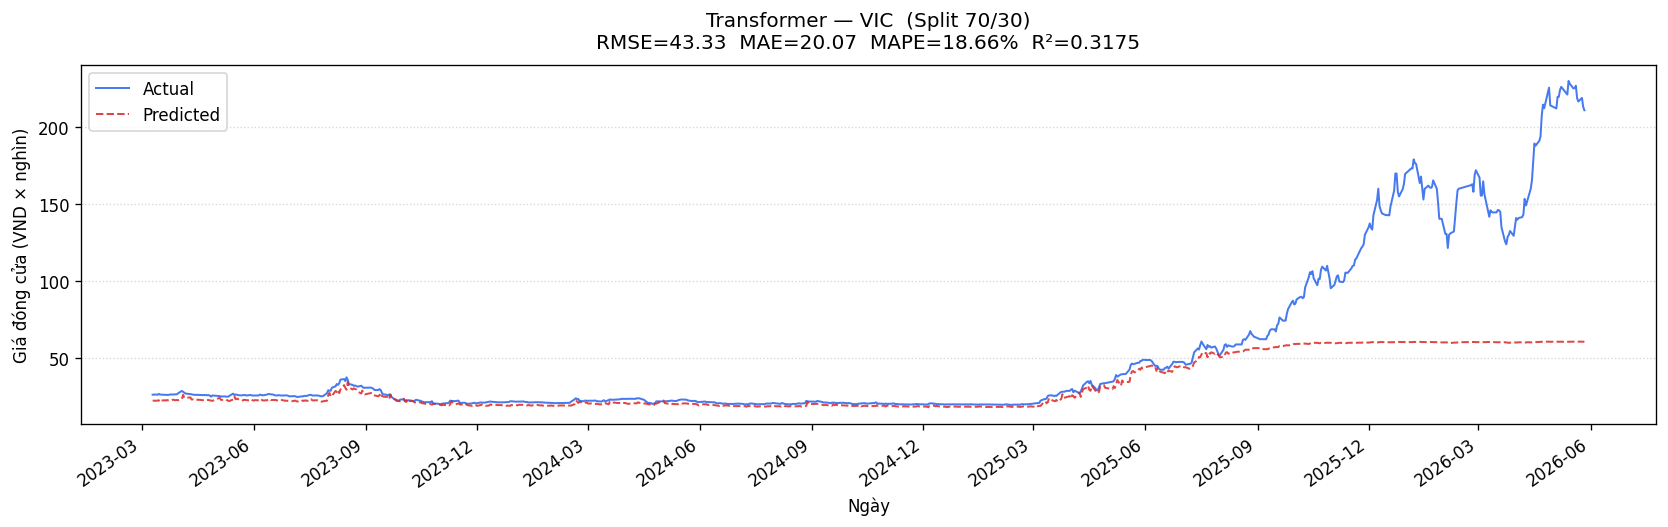


  > VNM...
     RMSE=1.01  MAE=0.71  MAPE=1.16%  R2=0.9317  DA=56.5%


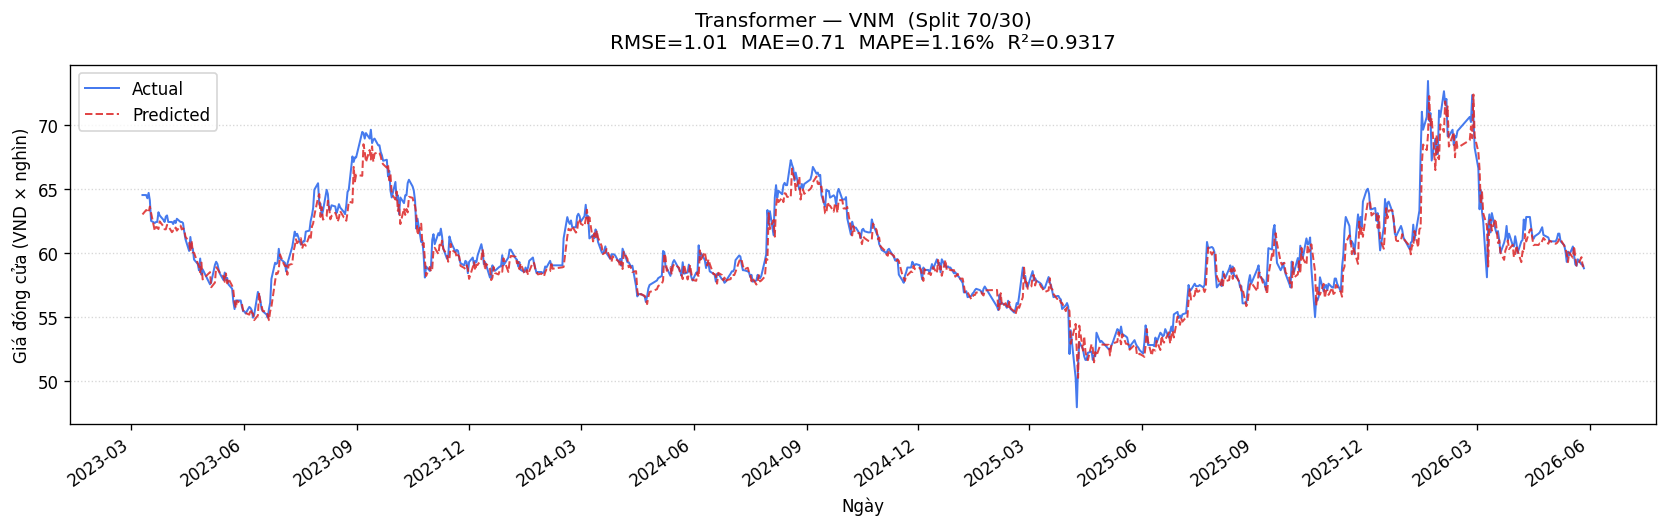


  Split: 80/20

  > VCB...
     RMSE=2.70  MAE=2.10  MAPE=3.42%  R2=0.3281  DA=53.8%


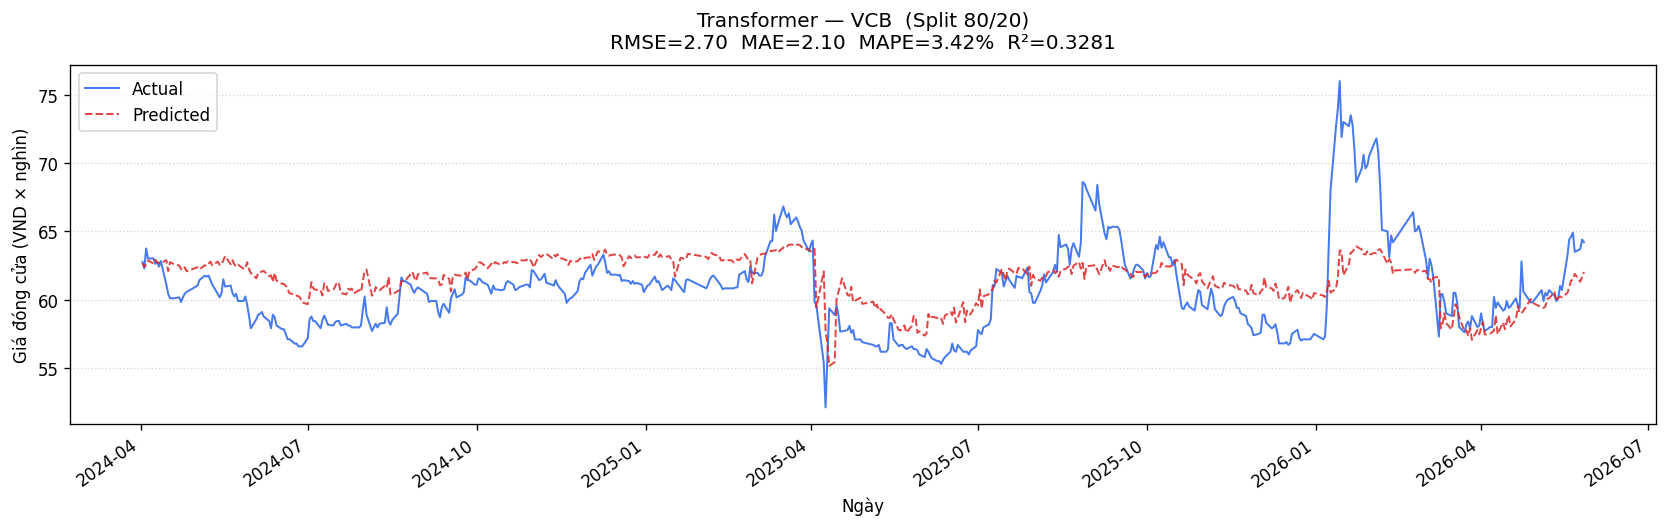


  > FPT...
     RMSE=9.47  MAE=7.04  MAPE=6.57%  R2=0.5458  DA=51.6%


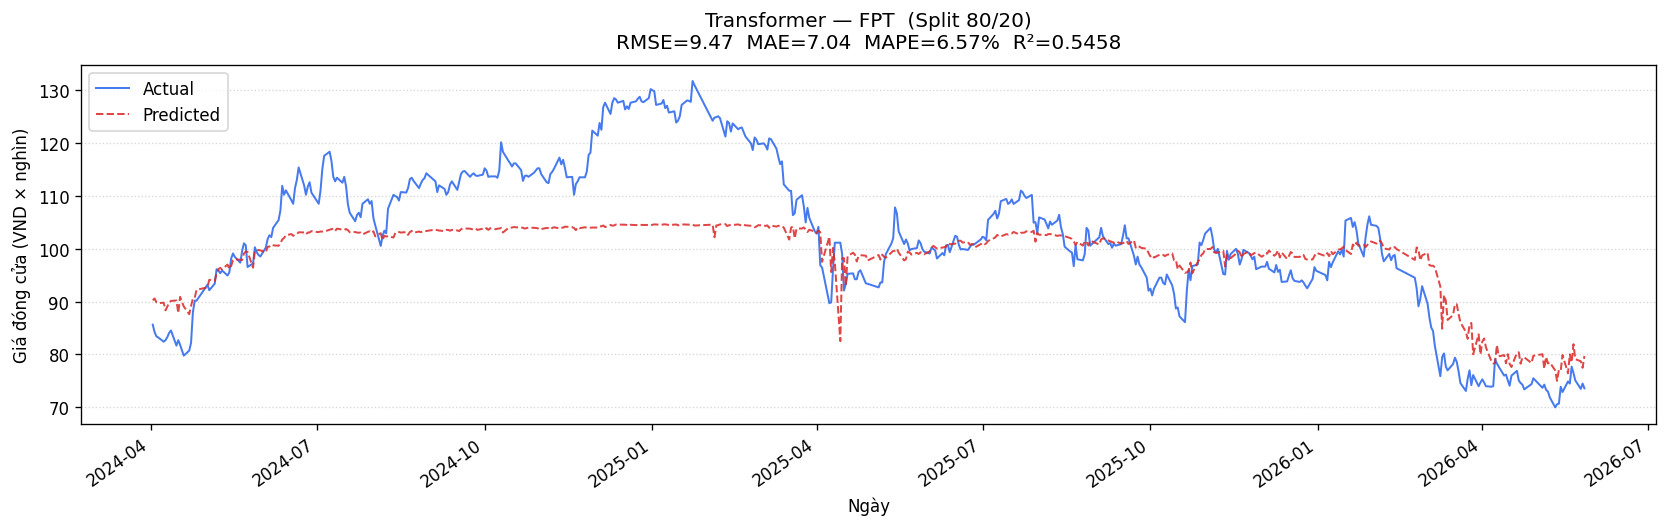


  > HPG...
     RMSE=1.13  MAE=0.94  MAPE=4.28%  R2=0.7646  DA=51.6%


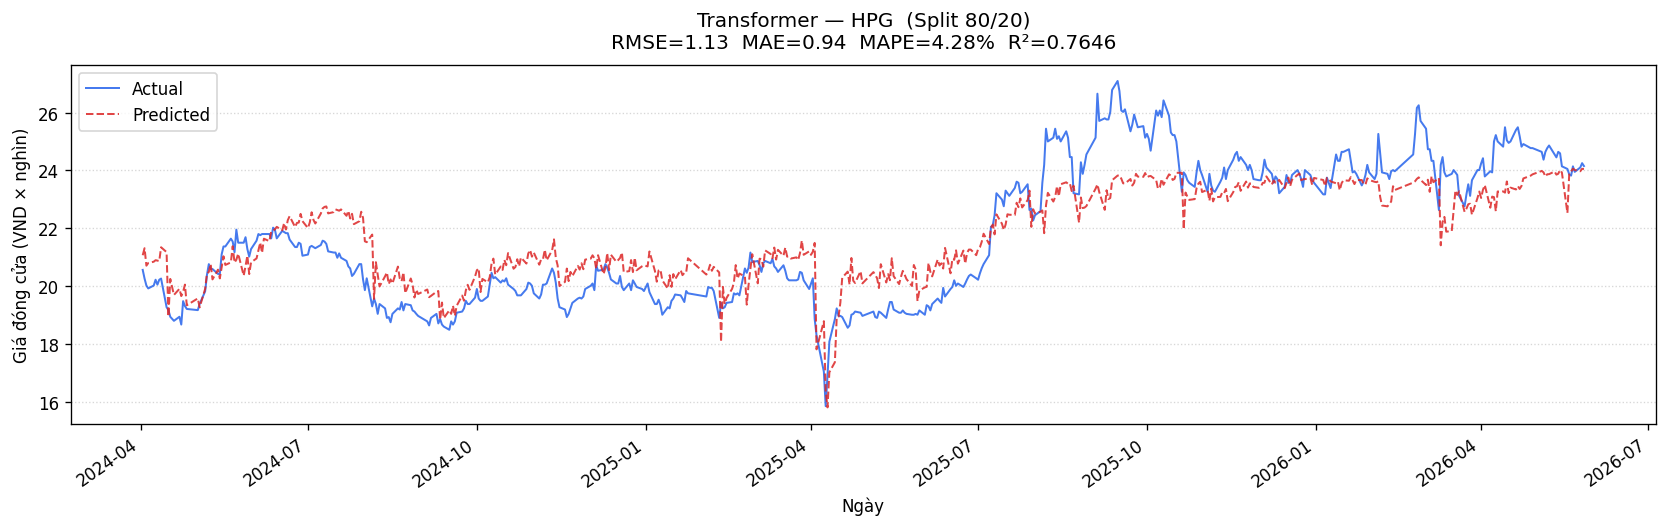


  > VIC...
     RMSE=53.15  MAE=27.81  MAPE=19.59%  R2=0.1995  DA=48.4%


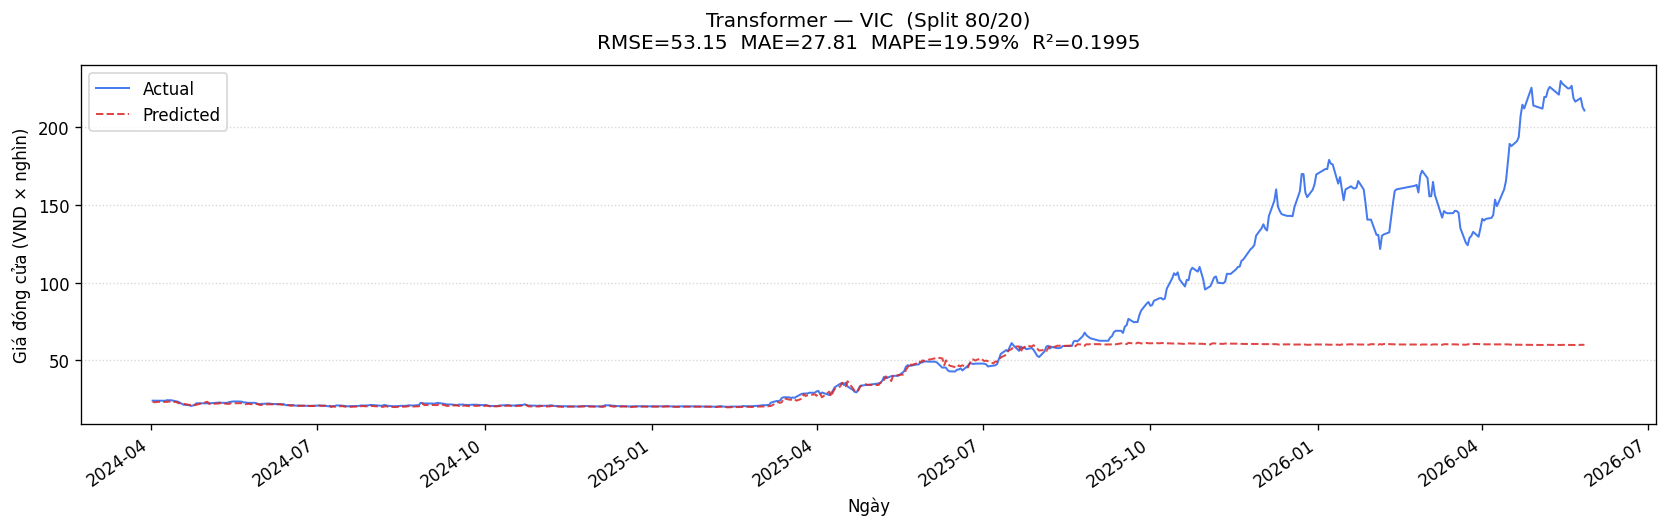


  > VNM...
     RMSE=1.20  MAE=0.86  MAPE=1.41%  R2=0.9131  DA=54.3%


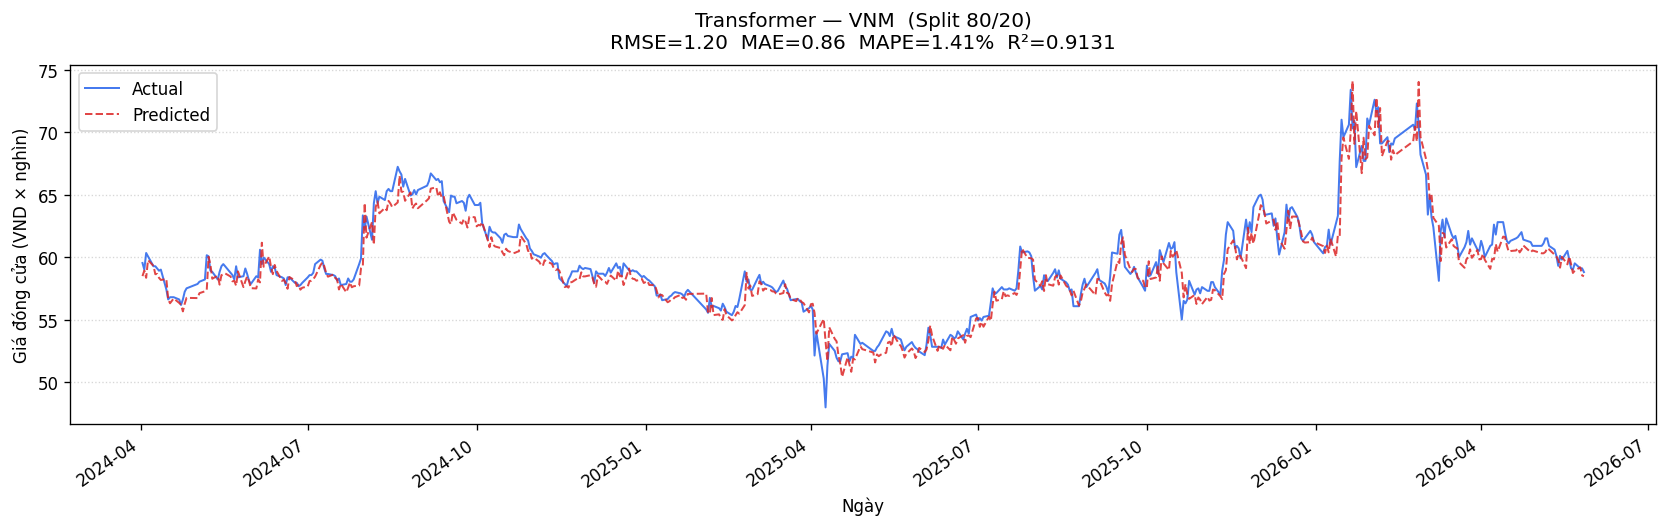

In [40]:
prediction_cache = {}
all_results = []

for split in SPLITS:
    print()
    print('=' * 55)
    print('  Split:', split.replace('_', '/'))
    print('=' * 55)

    for ticker in TICKERS:
        print()
        print('  > ', ticker, '...', sep='')
        train_df, test_df = load_split(ticker, split)

        y_pred = train_and_predict(train_df, test_df)
        y_true = test_df['close'].values.astype(float)
        prediction_cache[(ticker, split)] = y_pred

        prev_close = np.concatenate([[train_df['close'].iloc[-1]], y_true[:-1]])
        metrics = compute_metrics(y_true, y_pred, prev_close=prev_close)
        da = metrics.get('Directional Accuracy (%)', float('nan'))
        print(
            '     RMSE={:,.2f}  MAE={:,.2f}  MAPE={:.2f}%  R2={:.4f}  DA={:.1f}%'.format(
                metrics['RMSE'],
                metrics['MAE'],
                metrics['MAPE (%)'],
                metrics['R²'],
                da,
            )
        )

        plot_predictions(
            dates=test_df['date'],
            y_true=y_true,
            y_pred=y_pred,
            ticker=ticker,
            split=split,
            model_name=MODEL_NAME,
            metrics=metrics,
        )

        all_results.append({'Ticker': ticker, 'Split': split, 'Model': MODEL_NAME, **metrics})


---
## Section 5 — Bảng tổng hợp kết quả

In [41]:
results_df = build_results_table(all_results)

print()
print('─' * 75)
print('  Kết quả:', MODEL_NAME)
print('─' * 75)
print(results_df.to_string(index=False))

# Lưu CSV để thành viên 1 tổng hợp báo cáo
out_csv = RESULTS_DIR / f'{MODEL_NAME.lower().replace(" ", "_")}_results.csv'
results_df.to_csv(out_csv, index=False)
print()
print('  Đã lưu ->', out_csv)



───────────────────────────────────────────────────────────────────────────
  Kết quả: Transformer
───────────────────────────────────────────────────────────────────────────
Ticker Split       Model  RMSE   MAE  MAPE (%)     R²  Directional Accuracy (%)
   FPT 70_30 Transformer  5.45  3.84     3.963 0.9408                     51.62
   HPG 70_30 Transformer  1.02  0.87     4.385 0.8843                     48.65
   VCB 70_30 Transformer  1.80  1.10     1.785 0.7878                     53.34
   VIC 70_30 Transformer 43.33 20.07    18.664 0.3175                     47.27
   VNM 70_30 Transformer  1.01  0.71     1.160 0.9317                     56.47
   FPT 80_20 Transformer  9.47  7.04     6.569 0.5458                     51.63
   HPG 80_20 Transformer  1.13  0.94     4.284 0.7646                     51.61
   VCB 80_20 Transformer  2.70  2.10     3.415 0.3281                     53.83
   VIC 80_20 Transformer 53.15 27.81    19.587 0.1995                     48.42
   VNM 80_20 Transformer

### Pivot theo RMSE — so sánh nhanh giữa các mã


In [42]:
pivot_rmse = results_df.pivot_table(index='Ticker', columns='Split', values='RMSE')
pivot_mae  = results_df.pivot_table(index='Ticker', columns='Split', values='MAE')

print('RMSE (VND × nghìn):')
print(pivot_rmse.round(2).to_string())
print()
print('MAE (VND × nghìn):')
print(pivot_mae.round(2).to_string())


RMSE (VND × nghìn):
Split   70_30  80_20
Ticker              
FPT      5.45   9.47
HPG      1.02   1.13
VCB      1.80   2.70
VIC     43.33  53.15
VNM      1.01   1.20

MAE (VND × nghìn):
Split   70_30  80_20
Ticker              
FPT      3.84   7.04
HPG      0.87   0.94
VCB      1.10   2.10
VIC     20.07  27.81
VNM      0.71   0.86


---
## Section 6 — Export to GitHub Pages Dashboard

Export predictions và metrics vào `docs/data/` để model xuất hiện trên dashboard của nhóm.  
**Không cần sửa** — chạy sau Section 5.

In [43]:
import json as _json

DOCS_DATA = ROOT / 'docs' / 'data'
DOCS_DATA.mkdir(parents=True, exist_ok=True)

_model_slug = MODEL_NAME.lower().replace(' ', '_')

pred_rows = []
for split in SPLITS:
    for ticker in TICKERS:
        train_df, test_df = load_split(ticker, split)
        y_pred = prediction_cache.get((ticker, split))
        if y_pred is None:
            y_pred = train_and_predict(train_df, test_df)
        y_true = test_df['close'].values.astype(float)

        for idx, row in test_df.reset_index(drop=True).iterrows():
            pred_rows.append({
                'date':      str(row['date'].date()),
                'actual':    round(float(y_true[idx]), 4),
                'predicted': round(float(y_pred[idx]), 4),
                'ticker':    ticker,
                'split':     split,
                'model':     MODEL_NAME,
            })

pred_df = pd.DataFrame(pred_rows)
pred_path = DOCS_DATA / f'{_model_slug}_predictions.csv'
pred_df.to_csv(pred_path, index=False)
print(f'Predictions -> {pred_path.relative_to(ROOT)}  ({len(pred_df)} rows)')

met_path = DOCS_DATA / f'{_model_slug}_metrics.csv'
results_df.to_csv(met_path, index=False)
print(f'Metrics     -> {met_path.relative_to(ROOT)}')

manifest_path = DOCS_DATA / 'manifest.json'
if manifest_path.exists():
    manifest = _json.loads(manifest_path.read_text())
else:
    manifest = {'models': [], 'last_updated': ''}

manifest['models'] = [m for m in manifest.get('models', []) if m['name'] != MODEL_NAME]
manifest['models'].append({
    'name':        MODEL_NAME,
    'predictions': f'data/{_model_slug}_predictions.csv',
    'metrics':     f'data/{_model_slug}_metrics.csv',
})
manifest['last_updated'] = pd.Timestamp.now().strftime('%Y-%m-%d')
manifest_path.write_text(_json.dumps(manifest, indent=2, ensure_ascii=False))
print(f'Manifest    -> {manifest_path.relative_to(ROOT)}  ({len(manifest["models"])} model(s))')


Predictions -> docs/data/transformer_predictions.csv  (6670 rows)
Metrics     -> docs/data/transformer_metrics.csv
Manifest    -> docs/data/manifest.json  (3 model(s))


---
## Ghi chú khi viết báo cáo

- **RMSE** (Root Mean Squared Error): đơn vị VND × nghìn — nhạy với outliers
- **MAE** (Mean Absolute Error): đơn vị VND × nghìn — giải thích trực quan hơn
- **MAPE** (%): sai số phần trăm — dùng để so sánh giữa các mã khác nhau mức giá
- **R²**: hệ số xác định — càng gần 1 càng tốt
- **Directional Accuracy** (%): % lần model dự đoán đúng hướng (tăng/giảm) so với ngày liền trước. Random ≈ 50%; > 55% là có skill về hướng. Quan trọng vì RMSE thấp không nhất thiết kéo theo dự đoán hướng tốt.

Khi viết báo cáo Chương 5, dùng cả 5 chỉ số. Mọi bảng phải thống nhất đơn vị.
Biểu đồ được lưu tại `results/<model_name>/plots/`.
